# Обучение с учителем - регрессия

## Введение <a class='anchor' id='intro'>

<img src='https://raw.githubusercontent.com/foobar167/articles/master/Machine_Learning/Brochure/data/Ris2.15-Nekotoryye-tipovyye-zadachi-mashinnogo-obucheniya.png' width=700>


**Обучение с учителем** = есть целевая переменная (таргет), которую мы предсказываем

<img src='https://evileg.com/media/uploads/2017/11/15/wnunvc.png'>

_Регрессия_ - таргет непрерывен
- Предсказание цен на дома
- Предсказание спроса на товары
- ...


_Классификация_ - Таргет принимает 2 (иногда k) значений
- Кредитный скоринг: вернет кредит (target=0) или нет (target=1)
- Определение вида животного по фото (0 - лев, 1 - пантера, 2 - леопард, ... , k - гепард)
- ...

**Обучение без учителя** = нет целевой переменной:
- Разделение данных на группы
- ...

**Обучение с подкреплением** - испытуемая система (агент) обучается, взаимодействуя с некоторой средой.

**ЭТАПЫ Data Science проекта:**
1. Определить бизнес проблему
2. Перевести бизнес проблему в ML-задачу
3. Выбрать подходящие ML и бизнес метрики
4. Загрузка данных
5. EDA: визуализация данных
6. **_Разбиение данных на train и test_**
7. Предобработка данных и feature engineering
8. **_Построение ML моделей_**
9. **_Оценка качества ML моделей и выбор наилучшей_**
10. Доказать бизнес-заказчику, что модель хорошо работает
11. Внедрение модели в production
12. Улучшение модели
13. Поддержка модели

**Подключение библиотек и скриптов**

In [1]:
# 1. Основные библиотеки
import numpy as np
import pandas as pd
import pickle   # сохранение модели

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 2. Разделение датасета
from sklearn.model_selection import train_test_split

# 3. Модели
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 4. Метрики качества
from sklearn.metrics import mean_squared_error as mse, r2_score as r2

**Пути к файлу**

https://drive.google.com/file/d/1RJk-fL5hRd6EBIkY5miVmwGx5IKyo7xn/view?usp=sharing

In [2]:
!gdown 1RJk-fL5hRd6EBIkY5miVmwGx5IKyo7xn -O housing.сsv

Downloading...
From: https://drive.google.com/uc?id=1RJk-fL5hRd6EBIkY5miVmwGx5IKyo7xn
To: D:\MyJupyterNotebook\Learning\GitHub\02_supervised_learning\housing.сsv

  0%|          | 0.00/1.53M [00:00<?, ?B/s]
 34%|###4      | 524k/1.53M [00:00<00:00, 1.13MB/s]
 68%|######8   | 1.05M/1.53M [00:00<00:00, 2.07MB/s]
100%|##########| 1.53M/1.53M [00:00<00:00, 2.47MB/s]
100%|##########| 1.53M/1.53M [00:00<00:00, 2.14MB/s]


In [3]:
DATASET_PATH = 'housing.сsv'
PREPARED_DATASET_PATH_TRAIN = 'housing_train.csv'
PREPARED_DATASET_PATH_TEST = 'housing_test.csv'

SCALER_FILE_PATH = 'scaler.pkl'
MODEL_FILE_PATH = 'model.pkl'

# Шаг 1. Загрузка данных <a class='anchor' id='load'>

In [4]:
df = pd.read_csv(DATASET_PATH, sep=',')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


# Шаг 2. EDA и очистка данных  <a class='anchor' id='eda'>

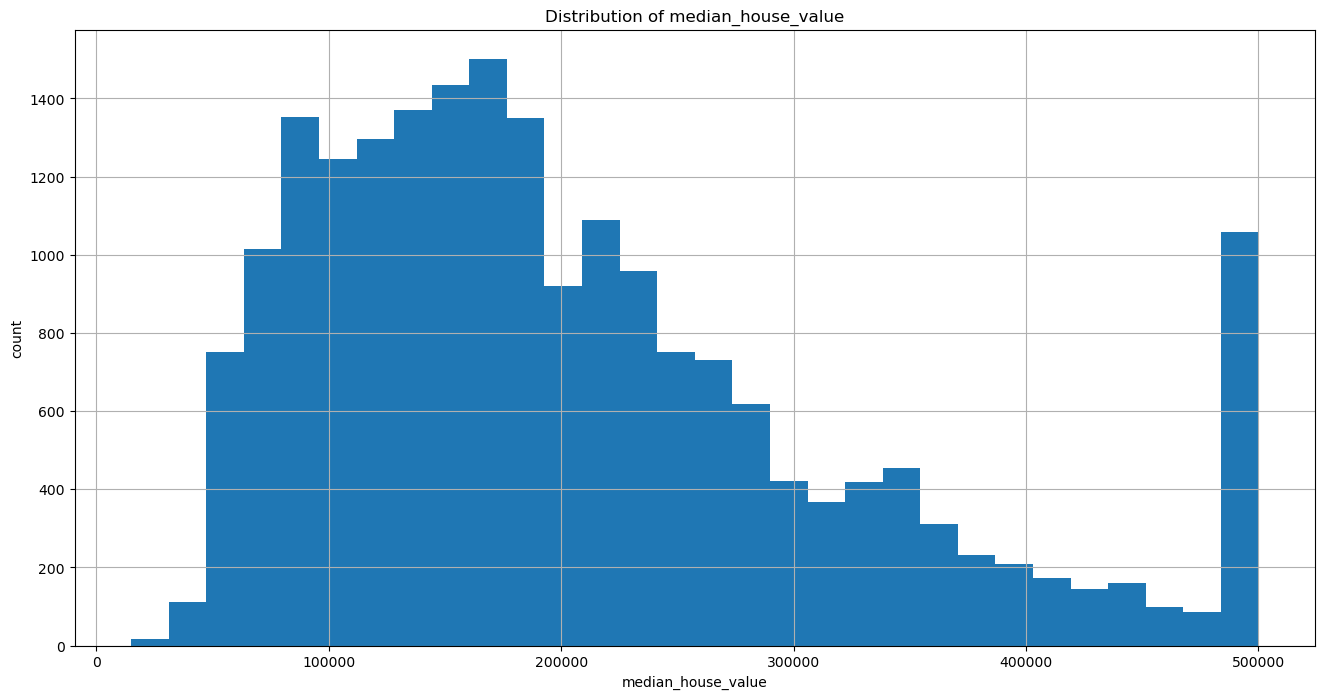

In [5]:
plt.figure(figsize=(16, 8))

df['median_house_value'].hist(bins=30)
plt.ylabel('count')
plt.xlabel('median_house_value')

plt.title('Distribution of median_house_value')
plt.show()

In [6]:
df = df[df['median_house_value'] <= 500000].reset_index()

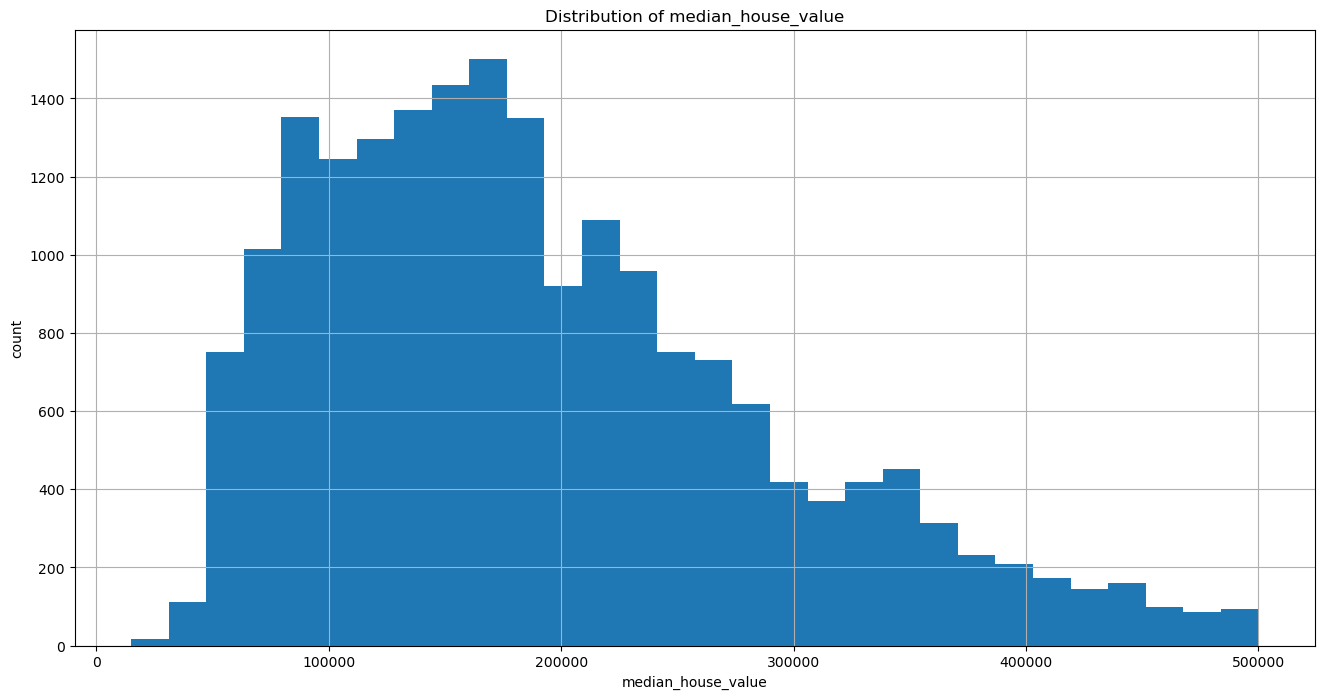

In [7]:
plt.figure(figsize=(16, 8))

df['median_house_value'].hist(bins=30)
plt.ylabel('count')
plt.xlabel('median_house_value')

plt.title('Distribution of median_house_value')
plt.show()

In [8]:
df.shape

(19675, 12)

# Шаг 3. Разбиение на train / val / test

<img src='https://miro.medium.com/max/1400/1*Nv2NNALuokZEcV6hYEHdGA.png'>

In [9]:
X = df.drop(columns='median_house_value')
y = df['median_house_value']

X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=100)
X_train_orig.index

Index([13827,  6764,   571, 18968,  5139,  5529, 18609, 11685,  5731, 10818,
       ...
        7906, 13890, 10082, 14260, 16734, 16304,    79, 12119, 14147,  5640],
      dtype='int64', length=13772)

In [10]:
X.shape

(19675, 11)

In [11]:
X_train_orig.shape, X_test_orig.shape

((13772, 11), (5903, 11))

# Шаг 4: Предобработка данных и Feature engineering  <a class='anchor' id='preprocess'>

In [12]:
df.describe()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,id
count,19675.000000,19675.000000,19675.000000,18996.000000,19675.000000,19475.000000,19101.000000,19675.000000,19675.000000,19675.000000,19675.000000
mean,10284.914917,-119.471937,35.027673,28.399663,2619.763659,539.645751,1440.763049,501.186023,3.676717,192477.921017,10284.914917
std,5986.729218,4.857772,97.202778,12.498073,2181.348207,422.413200,1146.357380,383.264636,1.570272,97711.509613,5986.729218
min,0.000000,-124.350000,-13534.030000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000,0.000000
25%,5040.500000,-121.760000,33.930000,18.000000,1438.000000,297.000000,795.000000,282.000000,2.526800,116600.000000,5040.500000
50%,10322.000000,-118.500000,34.270000,28.000000,2111.000000,436.000000,1177.000000,411.000000,3.450000,173800.000000,10322.000000
75%,15387.500000,-117.990000,37.730000,37.000000,3120.000000,648.000000,1749.000000,606.000000,4.582600,248200.000000,15387.500000
max,20639.000000,122.030000,1327.130000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500000.000000,20639.000000


In [13]:
df.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
0,0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2
3,3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,3
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


In [14]:
class DataPipeline:
    """Подготовка исходных данных"""

    def __init__(self):
        """Параметры класса"""
        self.longitude_max = None
        self.latitude_min = None
        self.latitude_max = None

        self.latitude_median = None
        self.longitude_median = None


    def fit(self, df):
        """Сохранение статистик"""

        # Расчет медиан
        self.longitude_max = 50
        self.latitude_min = -90
        self.latitude_max = 90

        self.latitude_median = df['latitude'].median()
        self.longitude_median = df['longitude'].median()


    def transform(self, df):
        """Трансформация данных"""

        df.loc[df['longitude'] > self.longitude_max, 'longitude'] = self.longitude_median
        df.loc[(df['latitude'] <= self.latitude_min) | (df['latitude'] > self.latitude_max), 'latitude'] = self.latitude_median


        if 'index' in df.columns:
            df.drop(columns='index', inplace=True)
        if 'id' in df.columns:
            df.drop(columns='id', inplace=True)
        if 'ocean_proximity' in df.columns:
            df.drop(columns='ocean_proximity', inplace=True)

        return df

In [15]:
pipe = DataPipeline()
pipe.fit(X_train_orig)

X_train = pipe.transform(X_train_orig)
X_test = pipe.transform(X_test_orig)

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13827,-117.23,32.80,22.0,2981.0,873.0,1751.0,745.0,2.3482
6764,-118.03,33.93,35.0,2470.0,416.0,1386.0,411.0,5.2736
571,-122.07,37.72,26.0,3204.0,477.0,1411.0,484.0,5.4834
18968,-119.30,36.31,16.0,2234.0,357.0,1150.0,361.0,4.2778
5139,-118.46,34.04,25.0,2768.0,850.0,1558.0,784.0,3.6976


In [16]:
pipe.latitude_max

90

---

### Пропуски

In [17]:
X_train.isna().sum()

longitude               0
latitude                0
housing_median_age    487
total_rooms             0
total_bedrooms        139
population            403
households              0
median_income           0
dtype: int64

In [18]:
from sklearn.impute import SimpleImputer


si = SimpleImputer(strategy='median')
si.fit(X_train)

si.statistics_

array([-118.49  ,   34.26  ,   28.    , 2121.    ,  438.    , 1181.    ,
        413.    ,    3.4478])

In [19]:
X_train_np = si.transform(X_train)
X_train_np

array([[-1.1723e+02,  3.2800e+01,  2.2000e+01, ...,  1.7510e+03,
         7.4500e+02,  2.3482e+00],
       [-1.1803e+02,  3.3930e+01,  3.5000e+01, ...,  1.3860e+03,
         4.1100e+02,  5.2736e+00],
       [-1.2207e+02,  3.7720e+01,  2.6000e+01, ...,  1.4110e+03,
         4.8400e+02,  5.4834e+00],
       ...,
       [-1.2140e+02,  3.8610e+01,  3.7000e+01, ...,  7.8200e+02,
         3.5500e+02,  4.1488e+00],
       [-1.1704e+02,  3.2540e+01,  7.0000e+00, ...,  1.1870e+03,
         2.8200e+02,  1.2667e+00],
       [-1.1833e+02,  3.4160e+01,  3.7000e+01, ...,  1.2350e+03,
         4.9900e+02,  3.7941e+00]], shape=(13772, 8))

In [20]:
X_train = pd.DataFrame(X_train_np, columns=X_train.columns)
X_train.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [21]:
X_test_np = si.transform(X_test)
X_test = pd.DataFrame(X_test_np, columns=X_train.columns)
X_test.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

### **Масштабирование признаков**

In [22]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-117.23,32.80,22.0,2981.0,873.0,1751.0,745.0,2.3482
1,-118.03,33.93,35.0,2470.0,416.0,1386.0,411.0,5.2736
2,-122.07,37.72,26.0,3204.0,477.0,1411.0,484.0,5.4834
3,-119.30,36.31,16.0,2234.0,357.0,1150.0,361.0,4.2778
4,-118.46,34.04,25.0,2768.0,850.0,1558.0,784.0,3.6976


In [23]:
feature_names_for_stand = X_train.columns
feature_names_for_stand

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

**Нормализация** - MinMaxScaler() Для каждой фичи x делает:
$$\frac{x_i - min}{max - min}$$
После нормализации признак будет изменяться в диапазоне [0, 1].<br>
Лучше зарекомендовала себя в моделях, которые работают с расстояниями (KNN).

<br>

**Стандартизация** - StandardScaler(). Для каждой фичи х делает:
$$\frac{x_i- mean}{std}$$
После стандартизации у признака будут mean = 0, std = 1.<br>
Лучше зарекомендовала себя в линейных моделях.

In [24]:
scaler = StandardScaler()

stand_features_train = scaler.fit_transform(X_train[feature_names_for_stand])
stand_features_test = scaler.transform(X_test[feature_names_for_stand])

In [25]:
scaler.mean_, scaler.var_

(array([-119.53028754,   35.63949463,   28.34526576, 2636.4875835 ,
         541.66649724, 1441.21434795,  503.95214929,    3.67246431]),
 array([6.09610276e+00, 4.63489969e+00, 1.49527829e+02, 4.81897867e+06,
        1.75586416e+05, 1.27897269e+06, 1.45550432e+05, 2.44208069e+00]))

In [26]:
stand_features_train

array([[ 0.93165686, -1.31892737, -0.51890613, ...,  0.27392437,
         0.63182458, -0.84741212],
       [ 0.60764281, -0.79404949,  0.54421399, ..., -0.04882265,
        -0.2436423 ,  1.02458533],
       [-1.02862816,  0.96638164, -0.19179225, ..., -0.02671669,
        -0.05229774,  1.15883879],
       ...,
       [-0.75726639,  1.37978104,  0.70777093, ..., -0.58290263,
        -0.39042716,  0.30481274],
       [ 1.0086102 , -1.43969574, -1.7455832 , ..., -0.22478608,
        -0.58177172, -1.53947653],
       [ 0.48613754, -0.68721594,  0.70777093, ..., -0.18234264,
        -0.01298037,  0.07783609]], shape=(13772, 8))

In [27]:
X_train[feature_names_for_stand] = stand_features_train
X_test[feature_names_for_stand] = stand_features_test

In [28]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,0.931657,-1.318927,-0.518906,0.156938,0.790715,0.273924,0.631825,-0.847412
1,0.607643,-0.794049,0.544214,-0.075841,-0.299898,-0.048823,-0.243642,1.024585
2,-1.028628,0.966382,-0.191792,0.258522,-0.154324,-0.026717,-0.052298,1.158839
3,0.093270,0.311446,-1.009577,-0.183347,-0.440700,-0.257503,-0.374700,0.387361
4,0.433485,-0.742955,-0.273571,0.059909,0.735826,0.103266,0.734050,0.016085


In [29]:
X_train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,1.377200e+04,1.377200e+04,1.377200e+04,1.377200e+04,1.377200e+04,1.377200e+04,1.377200e+04,1.377200e+04
mean,3.685308e-15,1.226372e-15,-5.159329e-18,-2.192715e-18,-8.512892e-17,-1.088618e-16,6.294381e-17,-4.707887e-18
std,1.000036e+00,1.000036e+00,1.000036e+00,1.000036e+00,1.000036e+00,1.000036e+00,1.000036e+00,1.000036e+00
min,-1.931817e+00,-1.439696e+00,-2.236254e+00,-1.200103e+00,-1.287894e+00,-1.269956e+00,-1.315696e+00,-2.030161e+00
25%,-8.828218e-01,-7.940495e-01,-8.460200e-01,-5.395765e-01,-5.743415e-01,-5.581440e-01,-5.765294e-01,-7.351076e-01
50%,4.213347e-01,-6.407666e-01,-2.823531e-02,-2.348230e-01,-2.473962e-01,-2.300915e-01,-2.384000e-01,-1.437653e-01
75%,6.278937e-01,9.663816e-01,6.259925e-01,2.258375e-01,2.543575e-01,2.544711e-01,2.753470e-01,5.806946e-01
max,4.841187e+01,2.931190e+00,1.934448e+00,1.671065e+01,1.352726e+01,3.027702e+01,1.272323e+01,7.248686e+00


### Сохранение  датасета

In [30]:
X_train.to_csv(PREPARED_DATASET_PATH_TRAIN, index=False, sep=';')
X_test.to_csv(PREPARED_DATASET_PATH_TEST, index=False, sep=';')

# Шаг 5. Построение моделей <a class='anchor' id='model'>

    
ML метрика - Mean Squared Error (**MSE**)
    - MSE прямопропорциональна RMSE и R^2
    - MSE  удобно оптимизировать (брать производные)
    - MSE используется "под капотом" наших ML моделей



Бизнес метрика - **R^2**, Root Mean Squared Error (**RMSE**)
    - Бизнес метрика интерпретируема
    - Понятна бизнесу
    - Ее мы показываем бизнесу
    - RMSE - насколько, в среднем, $ мы ошибаемся при предсказании цен
    - R^2 принимает значения от 0 до 1, если 1 - все предсказания идеальны. Можно сказать, что это "точность" модели

Лучшая модель - модель с наименьшей MSE на test

In [31]:
y      = np.array([100, 200, 100])
y_pred = np.array([105, 190, 80])

np.sqrt(np.mean((y - y_pred) ** 2))

np.float64(13.228756555322953)

 $$MSE = \frac{1}{n}  \sum{(y - y_{pred})^2}$$

$$RMSE = \sqrt{\frac{1}{n}  \sum{(y - y_{pred})^2}}$$

In [32]:
y      = np.array([100, 200, 100])
y_pred = np.array([1050, 1900, 800])

y_mean = np.array([133, 133, 133])

In [33]:
np.mean((y - y_pred) ** 2)

np.float64(1427500.0)

In [34]:
np.mean((y - y_mean) ** 2)

np.float64(2222.3333333333335)

In [35]:
1 - 1427500 / 2222

-641.4392439243925

$$R^2 = 1 - \frac{\frac{1}{n}\sum{(y - y_{pred})^2}}{\frac{1}{n}\sum{(y - y_{mean})^2}}$$

In [36]:
def evaluate_preds(true_values, pred_values, save=False):
    """Оценка качества модели и график preds vs true"""

    print("R2:\t" + str(round(r2(true_values, pred_values), 3)) + "\n" +
          "RMSE:\t" + str(round(np.sqrt(mse(true_values, pred_values)), 3)) + "\n" +
          "MSE:\t" + str(round(mse(true_values, pred_values), 3))
         )

    plt.figure(figsize=(8, 8))

    sns.scatterplot(x=pred_values, y=true_values)
    plt.plot([0, 500000], [0, 500000], linestyle='--', color='black')  # диагональ, где true_values = pred_values

    plt.xlabel('Predicted values')
    plt.ylabel('True values')
    plt.title('True vs Predicted values')

    if save == True:
        plt.savefig('report.png')
    plt.show()

### Linear Regression

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Linear_regression.svg/400px-Linear_regression.svg.png'>

y = wx + b

$$price_{pred} = a_0 + a_1 * households + a_2 * rooms + a_3*x_3 + a_4 * x_4$$

Подробное объяснение [здесь](https://youtu.be/KJA9A1q9l7E)

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
lr_model.coef_

array([-17876.27928737, -21500.50492044,  19445.17516643, -38929.59238214,
        32264.43937364, -30703.9898625 ,  43482.89844305,  71490.1642586 ])

In [39]:
lr_model.intercept_

np.float64(192273.8960935232)

In [40]:
y_train_preds = lr_model.predict(X_train)
y_train_preds.shape

(13772,)

In [41]:
np.sum(lr_model.coef_ * X_train.iloc[0].values) + lr_model.intercept_

np.float64(171770.53238924875)

In [42]:
y_train_preds[0]

np.float64(171770.53238924875)

In [43]:
np.clip([-10, 1, 100000, 1000000], a_min=10000, a_max=500000)

array([ 10000,  10000, 100000, 500000])

R2:	0.548
RMSE:	65452.328
MSE:	4284007266.382


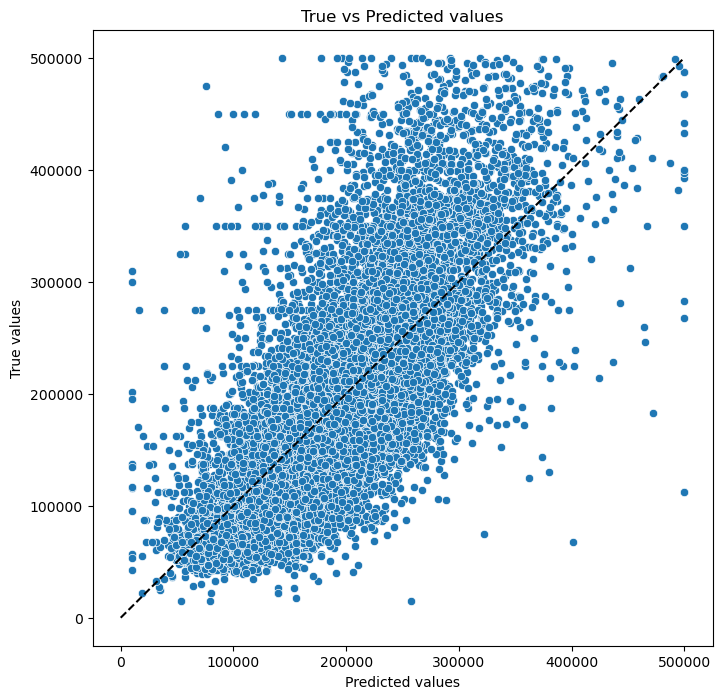

In [44]:
# Постпроцессинг
y_train_preds = np.clip(y_train_preds, a_min=10000, a_max=500000)

evaluate_preds(y_train, y_train_preds)

R2:	0.547
RMSE:	66405.42
MSE:	4409679760.994


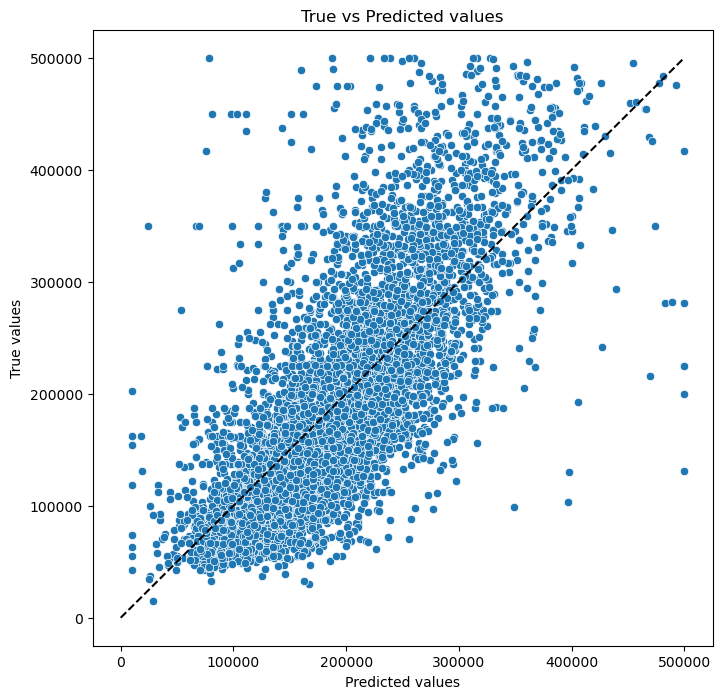

In [45]:
y_test_preds = lr_model.predict(X_test)

# Постпроцессинг
y_test_preds = np.clip(y_test_preds, a_min=10000, a_max=500000)

evaluate_preds(y_test, y_test_preds)

<img src='https://www.educative.io/api/edpresso/shot/6668977167138816/image/5033807687188480'>

# Шаг 6. Улучшение модели

In [46]:
from sklearn.base import BaseEstimator, TransformerMixin


class DataPipeline(BaseEstimator, TransformerMixin):
    """Подготовка исходных данных"""

    def __init__(self):
        """Параметры класса"""
        self.longitude_max = None
        self.latitude_min = None
        self.latitude_max = None

        self.latitude_median = None
        self.longitude_median = None


    def fit(self, df, y=None):
        """Сохранение статистик"""

        # Расчет медиан
        self.longitude_max = 50
        self.latitude_min = -90
        self.latitude_max = 90

        if 'latitude' in df.columns:
            self.latitude_median = df['latitude'].median()
        if 'longitude' in df.columns:
            self.longitude_median = df['longitude'].median()

        return self

    def transform(self, df, y=None):
        """Трансформация данных"""

        if 'longitude' in df.columns:
            df.loc[df['longitude'] > self.longitude_max, 'longitude'] = self.longitude_median
        if 'latitude' in df.columns:
            df.loc[(df['latitude'] <= self.latitude_min) | (df['latitude'] > self.latitude_max), 'latitude'] = self.latitude_median


        if 'index' in df.columns:
            df.drop(columns='index', inplace=True)
        if 'id' in df.columns:
            df.drop(columns='id', inplace=True)
        if 'ocean_proximity' in df.columns:
            df.drop(columns='ocean_proximity', inplace=True)

        return df

In [47]:
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    DataPipeline(),
    SimpleImputer(strategy='median'),
    StandardScaler()
)
pipe

,steps,"[('datapipeline', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [48]:
pipe.fit(X_train_orig, y_train)

,steps,"[('datapipeline', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [49]:
X_train = pipe.transform(X_train_orig)
X_test = pipe.transform(X_test_orig)

R2:	0.548
RMSE:	65452.328
MSE:	4284007266.382


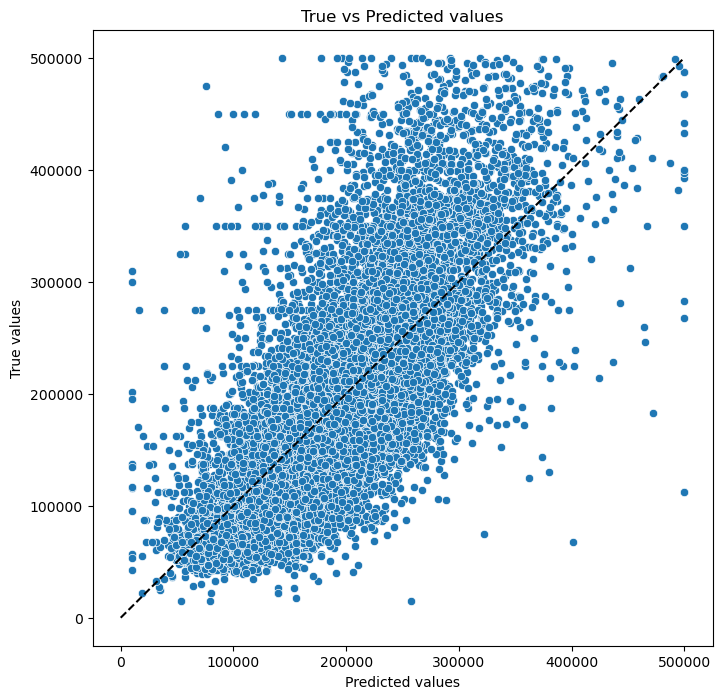

In [50]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_preds = lr_model.predict(X_train)
# Постпроцессинг
y_train_preds = np.clip(y_train_preds, a_min=10000, a_max=500000)

evaluate_preds(y_train, y_train_preds)

In [51]:
# y_test_preds = lr_model.predict(X_test)
# # Постпроцессинг
# y_test_preds = np.clip(y_test_preds, a_min=10000, a_max=500000)

# evaluate_preds(y_test, y_test_preds)

### PolynomialFeature

In [52]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(interaction_only=True)
poly.fit_transform(X_train_orig.iloc[:1])

array([[ 1.00000000e+00, -1.17230000e+02,  3.28000000e+01,
         2.20000000e+01,  2.98100000e+03,  8.73000000e+02,
         1.75100000e+03,  7.45000000e+02,  2.34820000e+00,
        -3.84514400e+03, -2.57906000e+03, -3.49462630e+05,
        -1.02341790e+05, -2.05269730e+05, -8.73363500e+04,
        -2.75279486e+02,  7.21600000e+02,  9.77768000e+04,
         2.86344000e+04,  5.74328000e+04,  2.44360000e+04,
         7.70209600e+01,  6.55820000e+04,  1.92060000e+04,
         3.85220000e+04,  1.63900000e+04,  5.16604000e+01,
         2.60241300e+06,  5.21973100e+06,  2.22084500e+06,
         6.99998420e+03,  1.52862300e+06,  6.50385000e+05,
         2.04997860e+03,  1.30449500e+06,  4.11169820e+03,
         1.74940900e+03]])

In [53]:
-117.23 * 32.8, -117.23 * 22, -117.23 * 2981

(-3845.144, -2579.06, -349462.63)

In [54]:
X_train_orig.iloc[:1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13827,-117.23,32.8,22.0,2981.0,873.0,1751.0,745.0,2.3482


In [55]:
pipe = make_pipeline(
    DataPipeline(),
    SimpleImputer(strategy='median'),
    PolynomialFeatures(interaction_only=True),
    StandardScaler()
)
pipe

,steps,"[('datapipeline', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,degree,2


In [56]:
X_train = pipe.fit_transform(X_train_orig)
X_test = pipe.transform(X_test_orig)

In [57]:
X_train[0]

array([ 0.        ,  0.93165686, -1.31892737, -0.51890613,  0.15693773,
        0.79071485,  0.27392437,  0.63182458, -0.84741212,  1.26953907,
        0.5519051 , -0.13247487, -0.75547796, -0.24755622, -0.59726157,
        0.87505794, -0.65181149,  0.05134335,  0.63536806,  0.16008338,
        0.48434363, -0.96501608,  0.0135405 ,  0.57902966,  0.06224377,
        0.39738541, -0.84255672,  0.04845497, -0.0368579 ,  0.02025537,
       -0.28673594,  0.10232591,  0.2044381 ,  0.02104701,  0.06175101,
       -0.23291076, -0.07217583])

R2:	0.65
RMSE:	57586.512
MSE:	3316206382.12


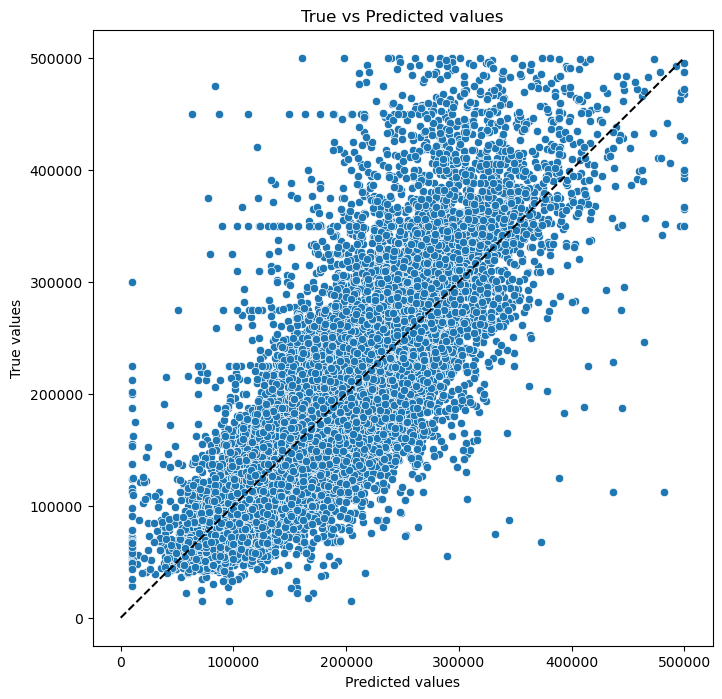

In [58]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_preds = lr_model.predict(X_train)
# Постпроцессинг
y_train_preds = np.clip(y_train_preds, a_min=10000, a_max=500000)

evaluate_preds(y_train, y_train_preds)

In [59]:
lr_model.coef_, lr_model.intercept_

(array([ 3.79243233e-08,  7.62695608e+04,  1.99494816e+05, -1.67494789e+06,
         2.86666445e+06, -3.13259757e+06,  9.57853396e+05, -8.51213902e+05,
        -1.25536342e+06,  1.31606503e+05, -2.39585445e+06,  4.32180095e+06,
        -4.53212581e+06,  1.47550195e+06, -1.46190056e+06, -1.87469601e+06,
        -7.15852606e+05,  1.36366136e+06, -1.30628720e+06,  5.05698106e+05,
        -6.16643917e+05, -5.67377777e+05,  3.29627215e+03, -6.39192072e+02,
        -2.76054908e+04,  2.89864308e+04,  9.12412819e+03,  3.34195661e+04,
        -1.12546120e+05,  9.25718795e+04,  7.38145158e+04,  4.79869207e+04,
        -1.47773757e+05, -4.37710864e+04,  8.02702406e+04, -9.18466909e+03,
         1.44948383e+04]),
 np.float64(192273.89609351833))

R2:	0.644
RMSE:	58851.44
MSE:	3463491962.406


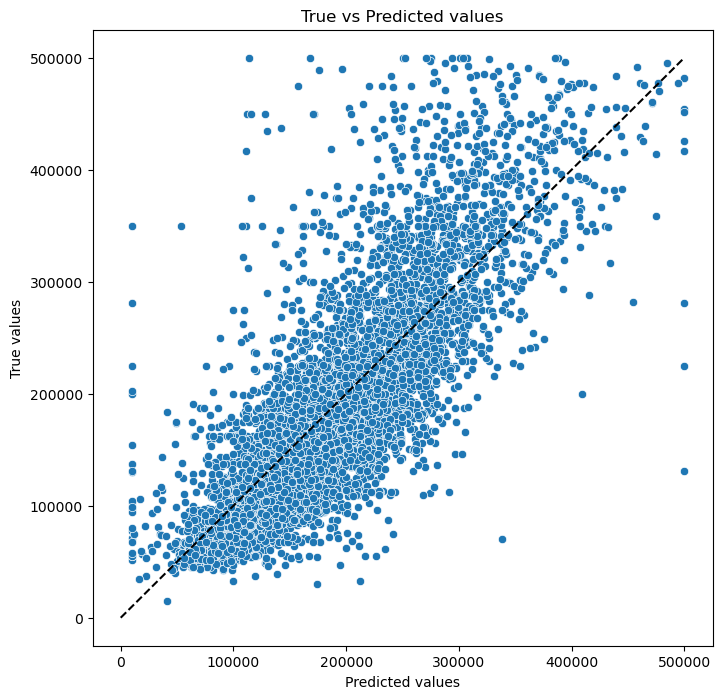

In [60]:
y_test_preds = lr_model.predict(X_test)

# Постпроцессинг
y_test_preds = np.clip(y_test_preds, a_min=10000, a_max=500000)

evaluate_preds(y_test, y_test_preds)

In [61]:
# poly = PolynomialFeatures(degree=3)
# poly.fit_transform(X_train_orig.iloc[:1])

In [62]:
pipe = make_pipeline(
    DataPipeline(),
    SimpleImputer(strategy='median'),
    PolynomialFeatures(degree=3),
    StandardScaler()
)
pipe

,steps,"[('datapipeline', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,degree,3


In [63]:
X_train = pipe.fit_transform(X_train_orig)
X_test = pipe.transform(X_test_orig)

In [64]:
X_train.shape

(13772, 165)

R2:	0.693
RMSE:	53927.81
MSE:	2908208661.726


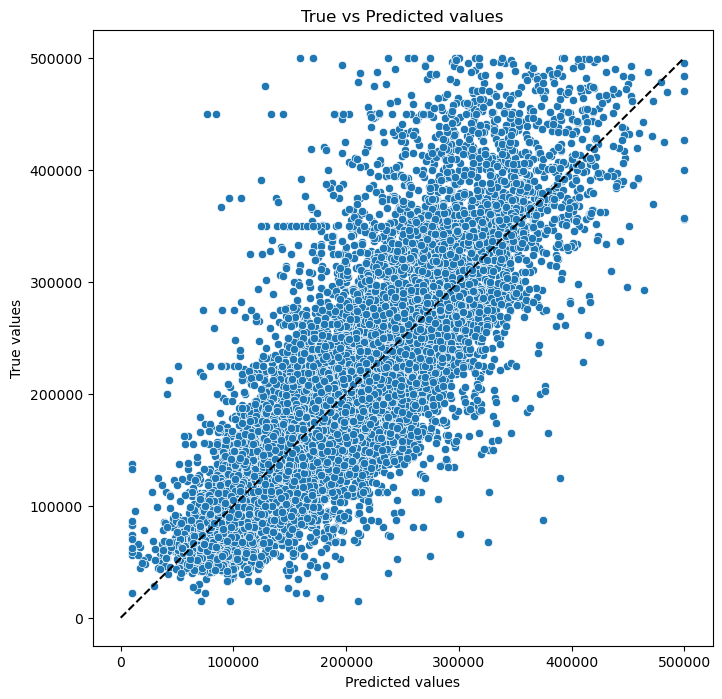

In [65]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_preds = lr_model.predict(X_train)
# Постпроцессинг
y_train_preds = np.clip(y_train_preds, a_min=10000, a_max=500000)

evaluate_preds(y_train, y_train_preds)

In [66]:
lr_model.coef_, lr_model.intercept_

(array([-1.21087688e-08, -3.15095321e+07,  2.23622145e+07,  1.35099013e+07,
         3.26092128e+07,  2.30195167e+07,  5.06765641e+07, -1.16818015e+08,
        -1.76153666e+06, -3.18483198e+07,  9.76527656e+07,  4.03009235e+07,
         6.68300198e+07,  9.47003381e+07,  9.14923337e+07, -2.87423057e+08,
         1.13530446e+06,  3.17337783e+07,  1.28643608e+07,  3.34026691e+06,
         4.34951304e+07, -1.27265584e+07, -4.63939967e+07,  2.91418904e+06,
        -2.16336557e+05,  1.00526629e+06,  3.42273684e+05,  1.30451064e+06,
        -2.80684764e+06, -3.17220788e+05, -7.28069798e+06, -1.79636399e+06,
         3.73693704e+05,  1.22187435e+07,  1.71891655e+06,  8.79580355e+06,
        -1.10124246e+07,  4.33077693e+06, -4.60066155e+05, -5.07328171e+06,
         1.86151235e+07,  4.73387431e+06, -2.04439923e+07, -6.81067897e+06,
         7.80248915e+05,  2.74742767e+06,  9.81575531e+07,  2.85673476e+07,
         3.98159481e+07,  7.64354107e+07,  3.61675602e+07, -1.80115739e+08,
         4.0

R2:	0.668
RMSE:	56838.629
MSE:	3230629771.39


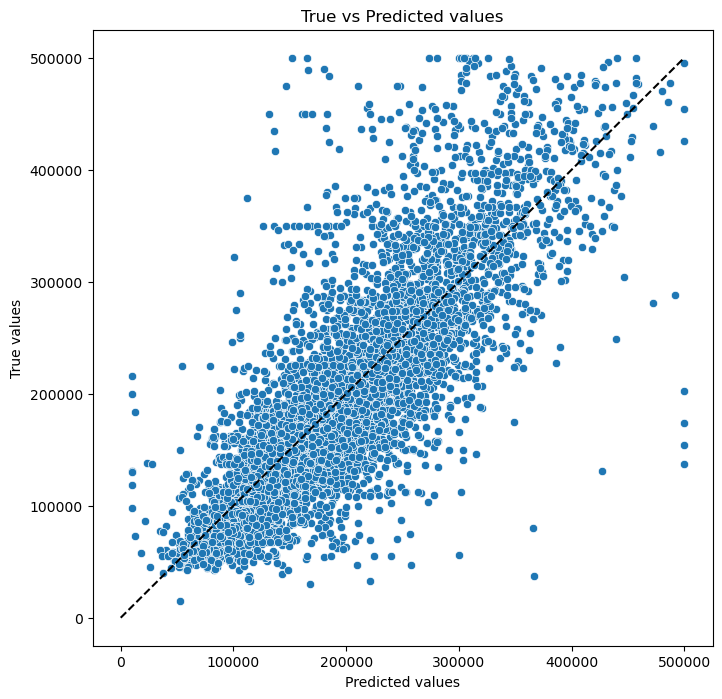

In [67]:
y_test_preds = lr_model.predict(X_test)

# Постпроцессинг
y_test_preds = np.clip(y_test_preds, a_min=10000, a_max=500000)

evaluate_preds(y_test, y_test_preds)

# Шаг 7. Сохранение модели <a class='anchor' id='save'>

In [68]:
with open(SCALER_FILE_PATH, 'wb') as filename:
    pickle.dump(scaler, filename)

In [69]:
with open(MODEL_FILE_PATH, 'wb') as filename:
    pickle.dump(lr_model, filename)

In [70]:
with open(MODEL_FILE_PATH, 'rb') as filename:
    my_model = pickle.load(filename)

my_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [71]:
import sklearn
print(sklearn.__version__)

1.7.2


In [72]:
!pip freeze #>> requirements.txt

# **Дополнительные материалы**

1. Виды машинного обучения (supervised, unsupervised) https://youtu.be/ku2oPMPht2I
2. Масштабирование данных - https://youtu.be/XsuCOfpf8Ic
2. Линейная регрессия - https://codecamp.ru/blog/introduction-to-linear-regression-python/
2. Линейная регрессия (видео) - https://youtu.be/KJA9A1q9l7E
2. Недообучение и переобучение (видео) - https://youtu.be/m7P7bnLxIc4
3. Машинное обучение для людей - https://vas3k.ru/blog/machine_learning/
9. Метрики для регрессии (видео) - https://youtu.be/vh2smjQyhp8